EC ENG 232E - Summer 25 - Project 4 (Part 1)

Team members:
*   Kaylee Lo (UID: 005-307-797), kayleelo@g.ucla.edu
*   Joanna Tang (UID: 602-503-690), joannat@g.ucla.edu
*   Rachel Zhang (UID: 705-413-148), rzhang319@g.ucla.edu

In [1]:
if (!require("igraph")) install.packages("igraph")
library ("igraph")
if (!require("clevr")) install.packages("clevr")
library ("clevr")
# https://cran.r-project.org/web/packages/clevr/index.html

Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: clevr



In [2]:
#unzip('finance_data.zip')

In [3]:
path = "finance_data/data/"
out.file<-""
file.names <- dir(path, pattern =".csv")
m <- matrix(, nrow = 0, ncol = 765)
sectors.table <- read.table("finance_data/Name_sector.csv",header=TRUE, sep=",", stringsAsFactors=TRUE)
sectors = c()
sectors.names <- c()
for(i in 1:length(file.names)){
    file <- read.table(paste("finance_data/data/",file.names[i],sep = ""),header=TRUE, sep=",", stringsAsFactors=FALSE)
    if(length(file$Close)==765){
        m <- rbind(m, matrix(file$Close, nrow=1, ncol=765))
        mystr <- substr(file.names[i], 1, nchar(file.names[i])-4)
        sector <- sectors.table$Sector[which(sectors.table$Symbol == mystr)]
#         print(sector)
#        sectors = c(sectors, as.factor(sector))
        sectors.names = c(sectors.names, toString(sector))
    }
}
com_num = length(sectors.names)
data_num = ncol(m)
sector.set<-as.factor(sectors.names)
sectors.index<-as.numeric(sector.set)
num_sector <- length(unique(sectors.index))
table(sector.set)

# 2014/5/1 - 2017/5/12
# 3 min

sector.set
    Consumer Discretionary           Consumer Staples 
                        84                         36 
                    Energy                 Financials 
                        34                         63 
               Health Care                Industrials 
                        60                         64 
    Information Technology                  Materials 
                        66                         24 
               Real Estate Telecommunication Services 
                        31                          4 
                 Utilities 
                        28 

In [4]:
#unique(sectors.table) # 505x2 # symbol, sector
# length(sectors.names) # 494
# length(sector.set) # 84+34+60+66+31+28+36+63+64+24+4 = 494
# m #494 x 765
# num_sector #11
com_num

[1] 494

# Return Correlation

## Q1.  What are upper and lower bounds on ρ_ij? 

Answers: $\rho_{ij}$ has an upper bound of 1 and a lower bound of -1. Since we are comparing across multiple sectors, it is more consistent to use the log-normalized return rather than the regular return when comparing stocks.

Provide a justification for using log-normalized return $(r_i(t))$ instead of regular return $(q_i(t))$.

$$p_i(t)$$ is the closing price of stock $i$ at the $i^{th}$ day.
$$q_i(t)$$ is the return of stock $i$ over a period of [t-1, t]. 
$$ q_i(t) = \frac{p_i(t) - p_i(t - 1)}{p_i(t-1)} $$
$$r_i(t)$$ is the log-normalized return stock $i$ over a period of [t-1, t].
$$ r_i(t) =log (1 + q_i(t))$$

correlation $$ \rho_{ij} = \frac{⟨r_i(t) r_j(t)⟩ - ⟨r_i(t)⟩ ⟨r_j(t)⟩}
{\sqrt{(⟨r_i(t)^2⟩ - ⟨r_i(t)⟩^2)(⟨r_j(t)^2⟩ - ⟨r_j(t)⟩^2)}} $$

In [5]:
#correlation
cal_cor<-function(comp_date){
  #write code
    p <- comp_date # get closing price from comp_date, should have n stocks x m dates
    m <- ncol(p)
    n <- nrow(p)
    print (paste("cal cor n x m:", n, m))
    q <- (p[, 2:m] - p[, 1:(m-1)]) / p[, 1:(m-1)]  # list of return of stock over a period of [t − 1, t]   matrix size should be n stocks x (m-1) dates
    r <- log(1+q) # list of log-normalized return stock over a period of [t-1, t] matrix size should be n stocks x (m-1)
    #print (p[1,])
    #print (q[1,])
    #print (r[1,])

    rho = matrix(, nrow = n, ncol = n) # correlation matrix, size should be n x n 
    # since it is symmetric, use lower triangle only in loop
    for (i in c(1:n)){
        for (j in c(1:i)){  # use i not n
            rho[i,j] = (mean(r[i,] * r[j,]) - mean(r[i,]) * mean(r[j,])) /
          sqrt((mean(r[i,]^2) - mean(r[i,])^2) *
               (mean(r[j,]^2) - mean(r[j,])^2))
            if (i != j)
                rho[j,i] = rho[i,j]
        }
    }
    return(rho)
}

In [6]:
#m #494x765
#sectors.table #505
correlation_matrix <- cal_cor(m)
dim(correlation_matrix)

[1] "cal cor n x m: 494 765"


[1] 494 494

# Constructing correlation graphs

The correlation graph has the stocks as the nodes and the edge weights are given by the following expression:
$$ w_{ij} = \sqrt{2(1 - \rho_{ij})} $$
Compute the edge weights using the above expression and construct the correlation graph.

## Q2. Plot a histogram showing the un-normalized distribution of edge weights.

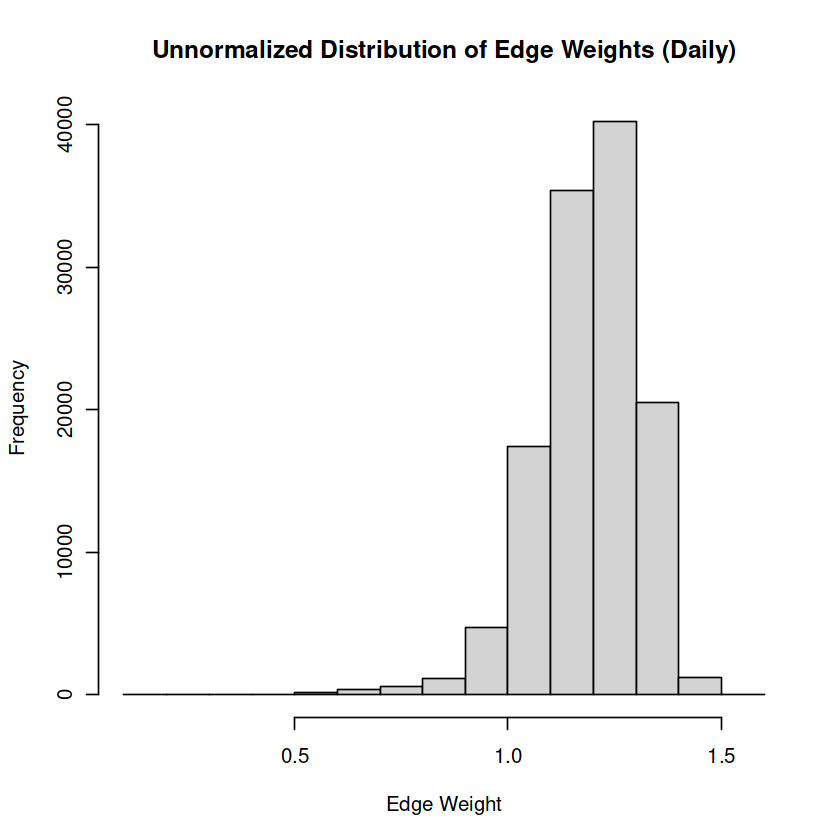

In [7]:
w <- matrix (, nrow = com_num, ncol = com_num)
for (i in c(1:com_num)){
    for (j in c(1:i)){
        w[i,j] = sqrt(2*(1 - correlation_matrix[i,j]))
        w[j,i] = w[i,j]
    }
}
#w
g <- graph_from_adjacency_matrix(w, mode ="upper", weighted = TRUE, diag = TRUE,
  add.colnames = NULL, add.rownames = NA)
hist(E(g)$weight, main = "Unnormalized Distribution of Edge Weights (Daily)", xlab = "Edge Weight")

#fname <- matrix(w)
save(w, file = "distance.RData")

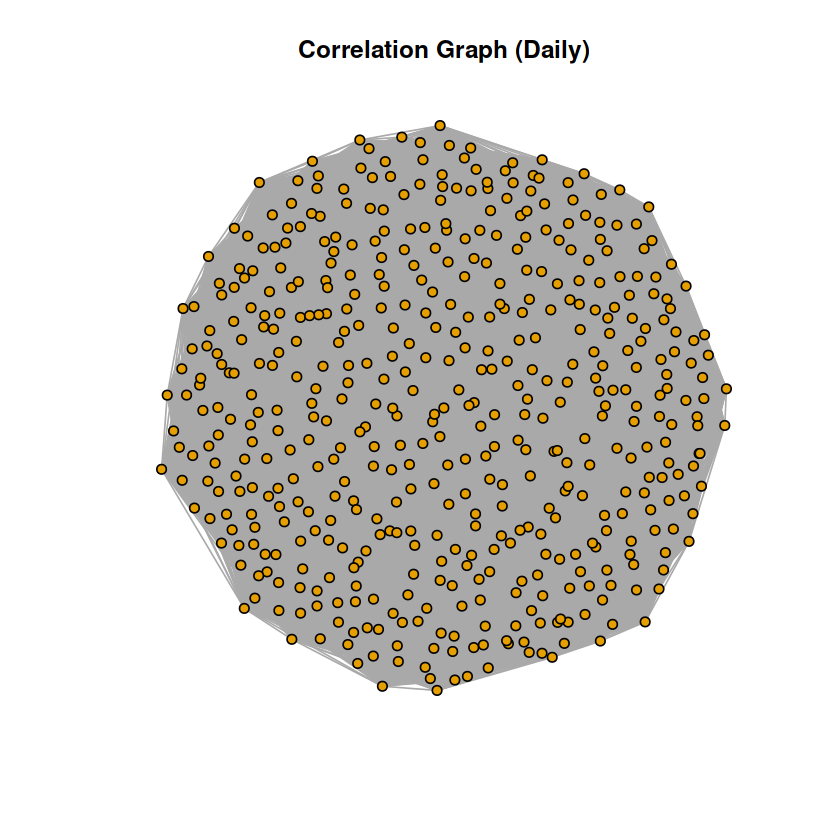

In [8]:
plot(g, vertex.label=NA, vertex.size=3, main="Correlation Graph (Daily)")

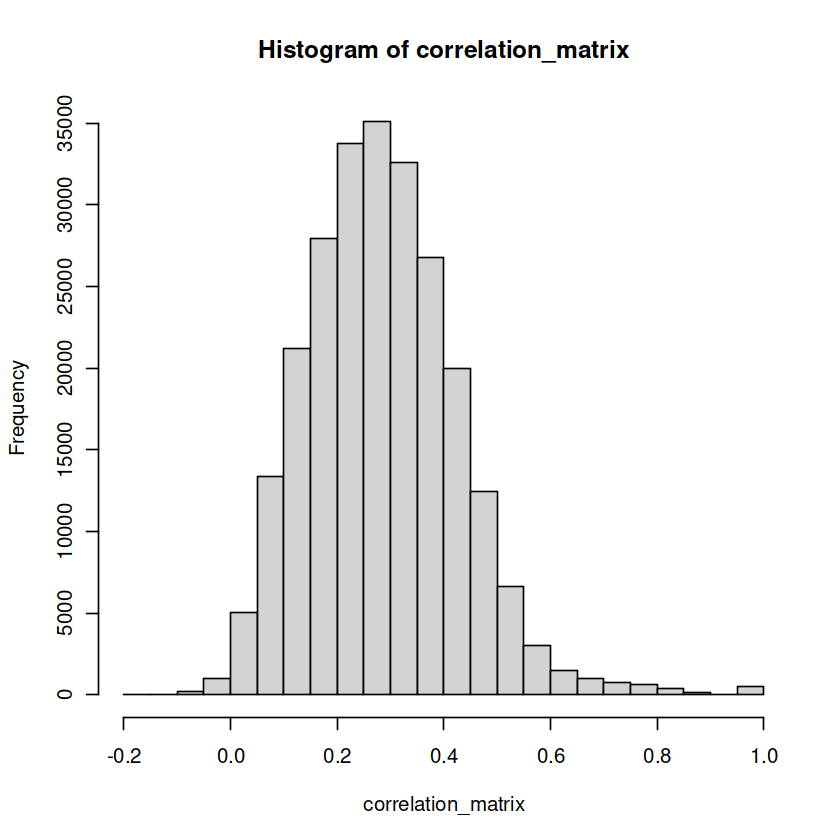

In [9]:
hist(correlation_matrix)

# Minimum spanning tree (MST)

## Q3. Plot the MST and color-code the nodes based on sectors. 

Each stock can be categorized into a sector, which can be found in Name sector.csv file. Plot the MST and color-code the nodes based on sectors.

Do you see any pattern in the MST? The structures that you find in MST are called Vine clusters. Provide a detailed explanation about the pattern you observe. 

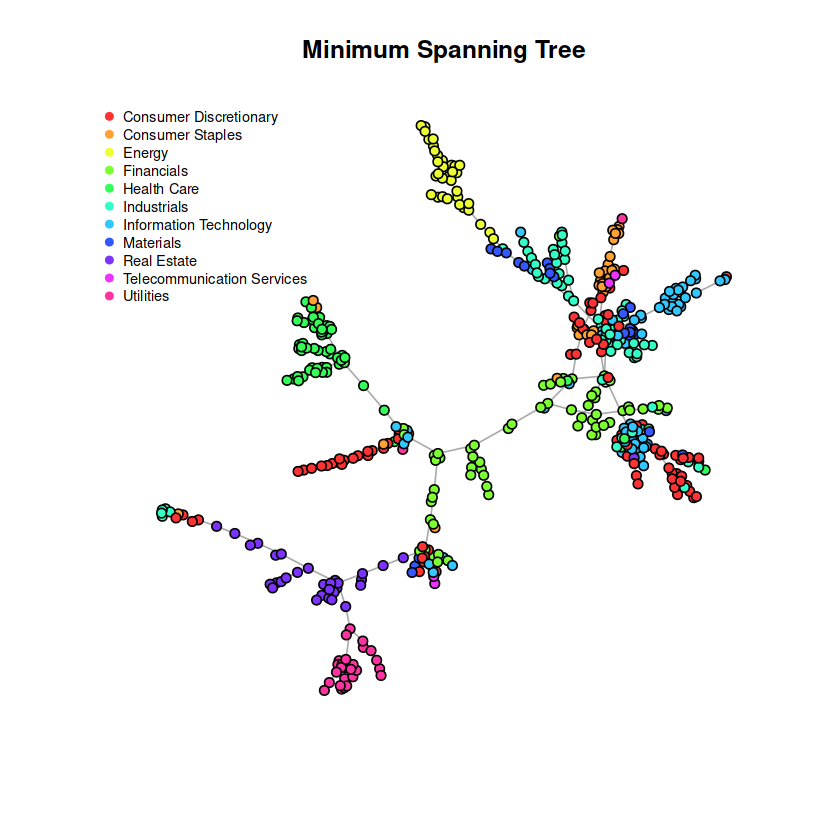

In [10]:
# build MST
mst_g <- mst(g, weights = E(g)$weight)

# plot MST  with sector color
colors <- rainbow(num_sector,s = 0.8, v = 1)
plot(mst_g,
    vertex.color = colors[sectors.index],
    vertex.size = 3,
    vertex.label = NA,
    main = "Minimum Spanning Tree")
legend("topleft",  
       legend = levels(sector.set),
       col = colors, pch=21, pt.bg=colors,
       cex=0.7, bty = "n")


Answer:  The plot illustrates a branching pattern where most nodes within a branch share similar colors, representing the same sectors.  The MST highlights the most crucial connections between individuals or groups in the network, revealing the most significant relationships. For example, the Energy and the Materials sectors share a branch of the tree, reflecting their close relationship. Similarly, stocks from the Information Technology and Financials tend to mix in a clump of nodes with other sectors, as they are often considered shared services. Stocks from the Real Estate and the Utilites sectors are also located in close proximity. 

## Q4.  Run a community detection algorithm (for example walktrap) on the MST obtained above. 

Run a community detection algorithm (for example walktrap) on the MST obtained above.

Plot the communities formed. Compute the homogeneity and completeness of the clustering. (you can use the ’clevr’ library in r to compute homogeneity and completeness).

[1] 33

[1] "Homegeneity:  0.682644648161366"
[1] "Completeness:  0.479284479244588"


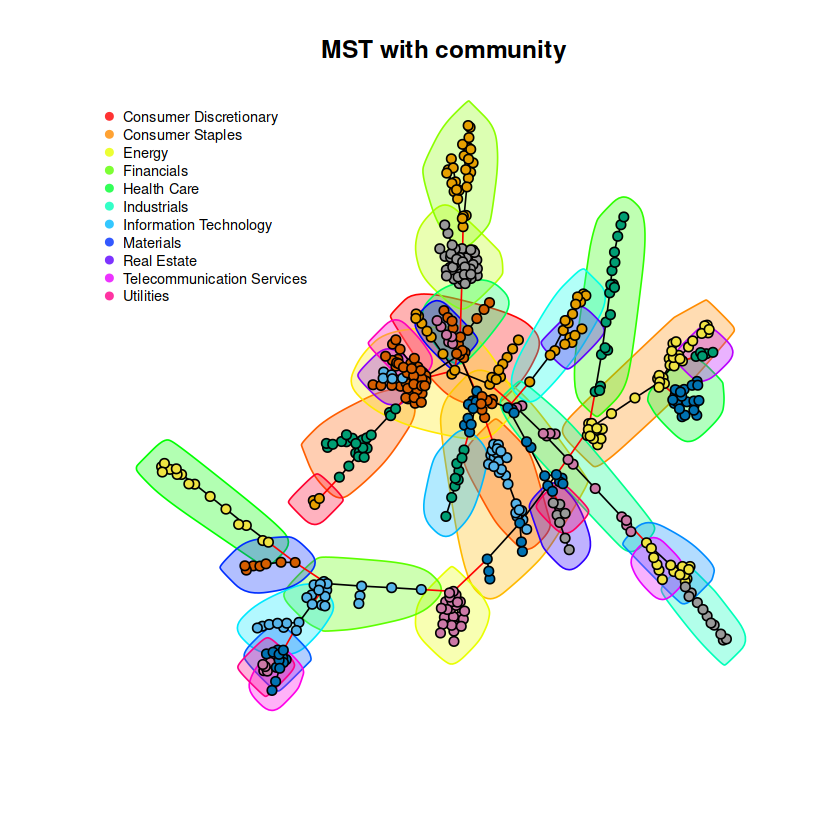

In [11]:
#cluster
wc_daily <- cluster_walktrap(mst_g)
length(wc_daily)
plot(wc_daily, mst_g, vertex.size=3, vertex.label=NA, 
    vertex.color=sectors.index, main="MST with community")
legend("topleft",  
       legend = levels(sector.set),
       col = colors, pch=21, pt.bg=colors,
       cex=0.7, bty = "n")

print(paste("Homegeneity: ", homogeneity(sectors.index, wc_daily$membership)))
print(paste("Completeness: ", completeness(sectors.index, wc_daily$membership)))

#get metrics
#true<- c(sectors.index)
#pred <- c(wc_daily$membership)
#homogeneity(true, pred)
#completeness(true,pred)

# Sector clustering in MST's

In order to evaluate the performance of the methods we define the following metric
$ \alpha = \frac{1}{|V|}\sum_{v_i∈V} P(v_i ∈ S_i) $,  where $S_i$ is the sector of node $i$. 

Define $$ P(v_i ∈ S_i) = \frac{|Q_i|}{|N_i|} $$ where $Q_i$ is the set of neighbors of node $i$ that belong to the same sector as node $i$ and $N_i$ is the set of neighbors of node $i$. 

Compare $\alpha$ with the case where $P(v_i ∈ S_i) = \frac{|S_i|}{|V|}$



## Q5. Report the value of α for the above two cases and provide an interpretation for the difference.

predict sector or unknown stock

In [12]:
V <- vcount(mst_g)
P1 <- 0
P2 <- 0

Si <- table(sectors.index)

for (vi in seq_len(V)){
    # get ni
    ni <- neighbors(mst_g, vi)  # neighbors of vi
    # get qi -- ni with same sector as vi
    if (length(ni) > 0)
        {
            current_sector = sectors.index[vi]
            qi <- intersect(ni, which(sectors.index == current_sector))
            P1 <- P1 + length(qi)/length(ni)
        }
    # get si - sector of vi
    si <- Si[current_sector] 
    #print(paste(current_sector, si, vi))
    P2 <- P2 + si/V
}

alpha1 <- P1/V
alpha2 <- P2/V

print(sprintf("Alpha (Daily) value for method 1 is: %s",alpha1))
print(sprintf("Alpha (Daily) value for method 2 is: %s",alpha2))

cat ("P1: ",  P1, "\n")
cat ("P2: ",  P2)

[1] "Alpha (Daily) value for method 1 is: 0.828930077530676"
[1] "Alpha (Daily) value for method 2 is: 0.114188070612532"
P1:  409.4915 
P2:  56.40891

**Answer:** In the context of the stock market, the first alpha, using $ \frac{|Q_i|}{|N_i|}  $, considered only the neighbors of a stock within the same sector. Predictions based on this measure are more restrictive and tend to follow localized trends. In contrast, the second alpha, using $ \frac{|S_i|}{|V|} $, considered the overall market. Predictions using this measure are more general, and reflect broader, global trends. 
Alpha using method 1 is higher than the alpha using method 2, indicating that the first method is more accurate in predicting the sector of an unknown stock.

# Correlation graphs for weekly data

## Q6. Repeat questions 2,3,4,5 on the WEEKLY data.

weekly

In [13]:
# load file with weekly data
# sample the stock data weekly on Mondays
# If there is a holiday on a Monday, we ignore that week.
path = "finance_data/data/"
out.file<-""
file.names <- dir(path, pattern =".csv")
sectors_w.table <- read.table("finance_data/Name_sector.csv",header=TRUE, sep=",", stringsAsFactors=TRUE)
sectors_w = c()
sectors_w.names <- c()
weekly_m <- matrix(,nrow=0, ncol=143)
for(i in 1:length(file.names)){
    file <- read.table(paste("finance_data/data/",file.names[i],sep = ""),header=TRUE, sep=",", stringsAsFactors=FALSE)

    Date_data<- file$Date
    weekdays_data <-weekdays(as.Date(Date_data)) #this gives weekday name     
    weekly_m_m <- file[weekdays_data == "Monday", 'Close'] #select data where week day is monday 
    #print (dim(weekly_m))
    #print(length(weekly_m_m))
    #print(dim(matrix(weekly_m_m)))
    #print(dim(t(matrix(weekly_m_m))))
    if(length(weekly_m_m) == 143){
        weekly_m <- rbind(weekly_m, matrix(weekly_m_m, nrow=1, ncol=143))
        mystr <- substr(file.names[i], 1, nchar(file.names[i])-4)
        sector <- sectors_w.table$Sector[which(sectors_w.table$Symbol == mystr)]
#         print(sector)
#        sectors = c(sectors, as.factor(sector))
        sectors_w.names = c(sectors_w.names, toString(sector))
    }
}
com_num = length(sectors_w.names)
data_num = ncol(weekly_m)
sector_w.set<-as.factor(sectors_w.names)
sectors_w.index<-as.numeric(sector_w.set)
num_sector <- length(unique(sectors_w.index))
table(sector_w.set)

# 2014/5/1 - 2017/5/12
# 143 Mondays

sector_w.set
    Consumer Discretionary           Consumer Staples 
                        84                         35 
                    Energy                 Financials 
                        34                         62 
               Health Care                Industrials 
                        60                         64 
    Information Technology                  Materials 
                        66                         24 
               Real Estate Telecommunication Services 
                        31                          4 
                 Utilities 
                        28 

[1] "cal cor n x m: 492 143"


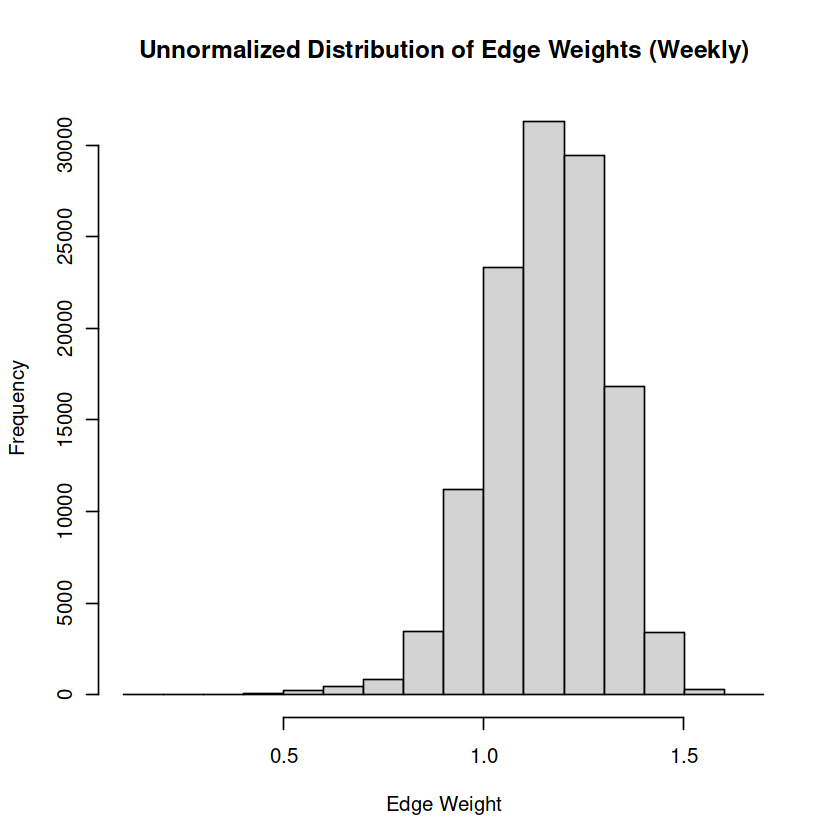

In [14]:
# weekly_m  492x143
week_m_cor <- cal_cor(weekly_m)
week_m_d <- sqrt(2 * (1 - week_m_cor))  #check formula from question pdf

week_m_g<-graph_from_adjacency_matrix(week_m_d, mode ="upper", weighted = TRUE, diag = TRUE,
  add.colnames = NULL, add.rownames = NA)

hist(E(week_m_g)$weight, main = "Unnormalized Distribution of Edge Weights (Weekly)", xlab = "Edge Weight")


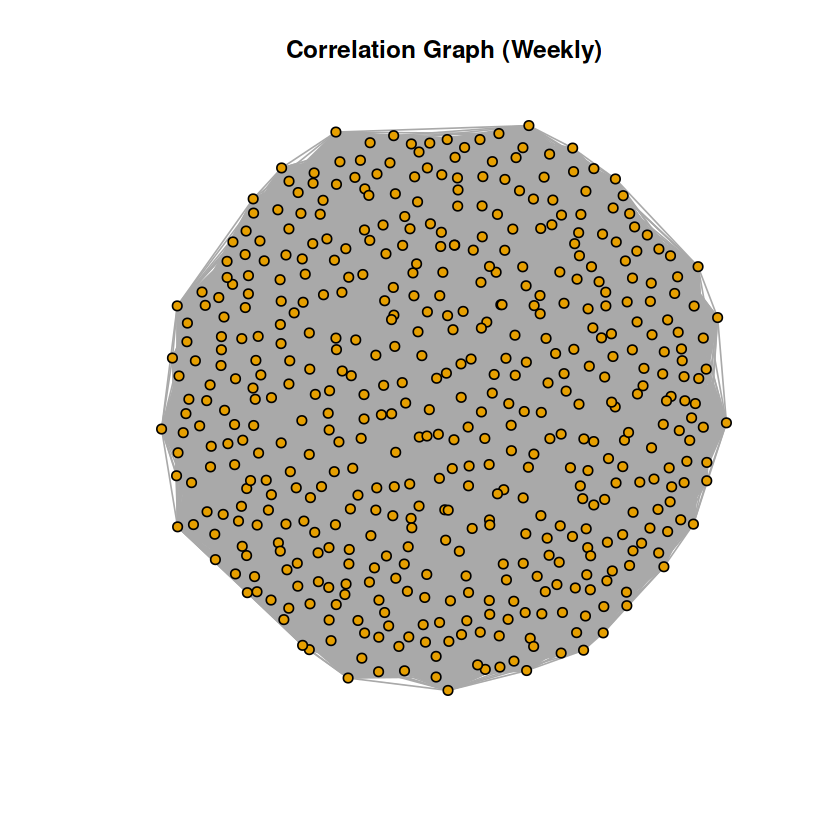

In [15]:
plot(week_m_g, vertex.label=NA, vertex.size=3, main="Correlation Graph (Weekly)")

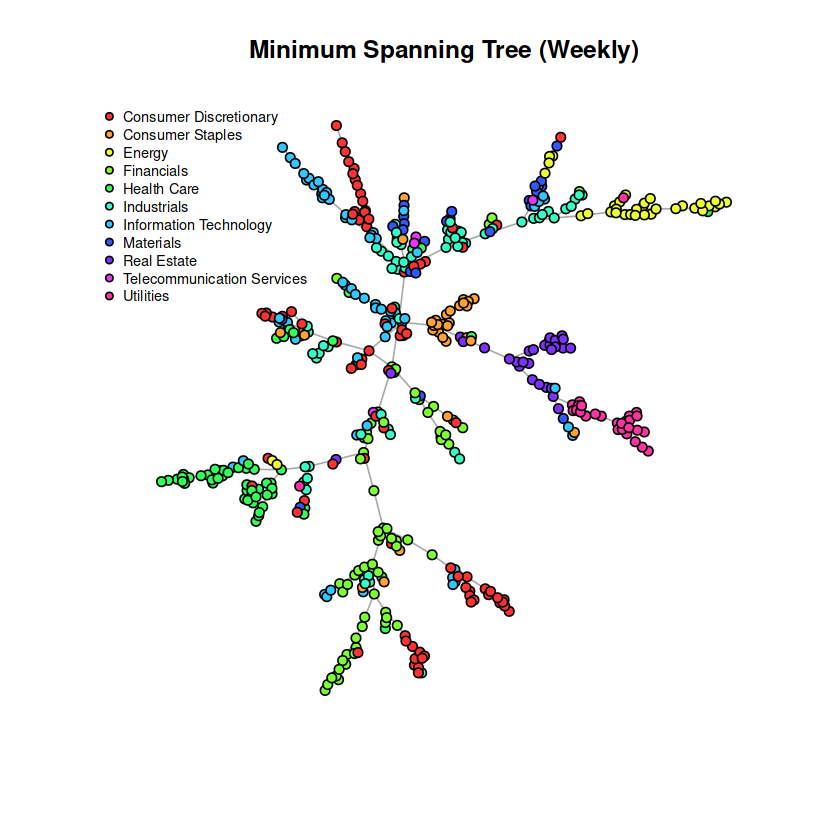

In [16]:
mst_week_m <- mst(week_m_g, weights = E(week_m_g)$weight) #use the mst function

colbar <- rainbow(num_sector,s = 0.8, v = 1)
plot(mst_week_m, vertex.size=3, vertex.label=NA, vertex.color=colbar[sectors_w.index],
    main = "Minimum Spanning Tree (Weekly)")
legend('topleft',legend=levels(sector_w.set),pch=21, pt.bg=colbar, cex=0.7, bty = "n")

**Q3 Answer:**  Although we still have the tree branches, the sectors merge more as we observe fewer single-color branches than in the daily MST. The sectors are more intermixed when sampling weekly sampling than when sampling daily. Several branches have lone-nodes of different colors, signaling possible misclassification. The MST is less clear (in terms of sector separation) and less accurate (misclassification) in the weekly sampling.

[1] 42

[1] "Homegeneity:  0.581123705715172"
[1] "Completeness:  0.390043529189446"


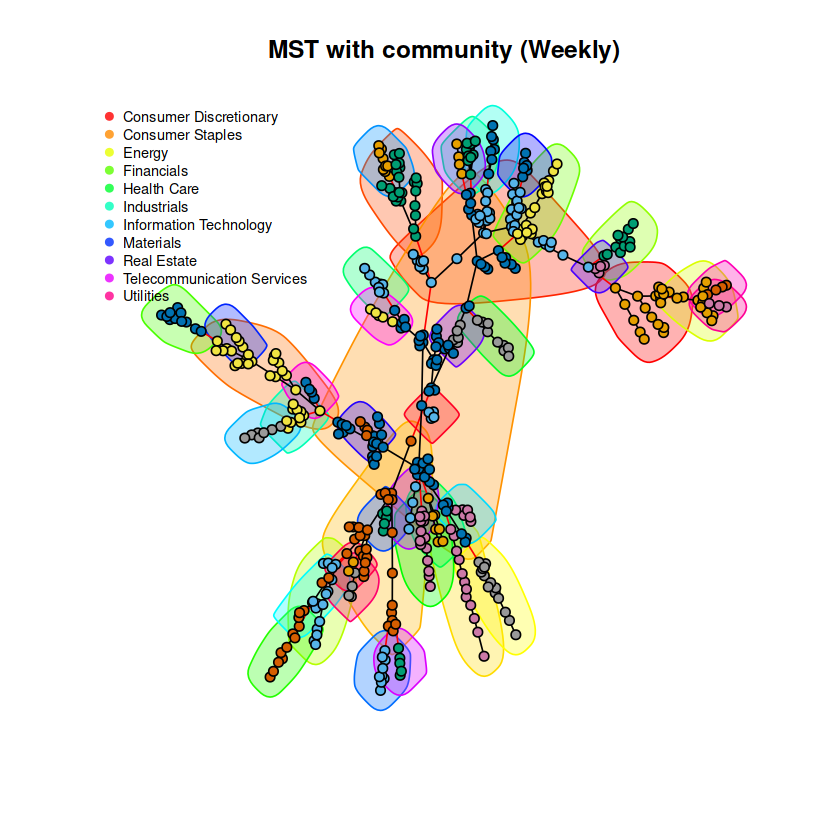

In [17]:
#cluster
wc_weekly <- cluster_walktrap(mst_week_m) #you can use walktrap.community. ensure that same algo is used for daily, monthly, weekly
length(wc_weekly)
plot(wc_weekly, mst_week_m, vertex.size=3, vertex.label=NA, 
    vertex.color=sectors_w.index, main="MST with community (Weekly)")
legend("topleft",  
       legend = levels(sector_w.set),
       col = colors, pch=21, pt.bg=colors,
       cex=0.7, bty = "n")

print(paste("Homegeneity: ", homogeneity(sectors_w.index, wc_weekly$membership)))
print(paste("Completeness: ", completeness(sectors_w.index, wc_weekly$membership)))


In [18]:
#get metrics
true<- c(sectors_w.index)
pred <- c(wc_weekly$membership)
homogeneity(true, pred)
completeness(true,pred)

[1] 0.5811237

[1] 0.3900435

In [19]:
V <- vcount(mst_week_m)
P1 <- 0
P2 <- 0

Si <- table(sectors_w.index)

for (vi in seq_len(V)){
    # get ni
    ni <- neighbors(mst_week_m, vi)  # neighbors of vi
    # get qi -- ni with same sector as vi
    if (length(ni) > 0)
        {
            current_sector = sectors_w.index[vi]
            qi <- intersect(ni, which(sectors_w.index == current_sector))
            P1 <- P1 + length(qi)/length(ni)
        }
    # get si - sector of vi
    si <- Si[current_sector] 
    #print(paste(current_sector, si, vi))
    P2 <- P2 + si/V
}

alpha1 <- P1/V
alpha2 <- P2/V

print(sprintf("Alpha (Weekly) value for method 1 is: %s",alpha1))
print(sprintf("Alpha (Weekly) value for method 2 is: %s",alpha2))

cat ("P1: ",  P1, "\n")
cat ("P2: ",  P2)

[1] "Alpha (Weekly) value for method 1 is: 0.743957284810943"
[1] "Alpha (Weekly) value for method 2 is: 0.114308612598321"
P1:  366.027 
P2:  56.23984

**Q5 Answer:**  The alpha value for method 1 is 0.7440, and the alpha value for method 2 is 0.1143. The alpha value for method 1 is higher than the alpha value for method 2, indicating that the first method is more accurate in predicting the sector of an unknown stock.

# Correlation graphs for MONTHLY data

## Q7. Repeat questions 2,3,4,5 on the MONTHLY data.

Monthly

In [20]:
# load file with Monthly data
# sample the stock data Monthly on 15th and
# If there is a holiday on the 15th, we ignore that month.

#dates_num <- #format(#write code here)
#monthly_15_m <- #select data where date is 15 

path = "finance_data/data/"
out.file<-""
file.names <- dir(path, pattern =".csv")
sectors_m.table <- read.table("finance_data/Name_sector.csv",header=TRUE, sep=",", stringsAsFactors=TRUE)
sectors_m = c()
sectors_m.names <- c()
monthly_15_m <- matrix(,nrow=0, ncol=25)
for(i in 1:length(file.names)){
    file <- read.table(paste("finance_data/data/",file.names[i],sep = ""),header=TRUE, sep=",", stringsAsFactors=FALSE)

    Date_data<- file$Date
    dates_num <- format(as.Date(Date_data), "%d") #format get day from date string
    # print(dates_num)
    monthly_m_m <- file[dates_num == "15", 'Close'] #select 15th of month
    #print(dim(monthly_15_m))
    #print(length(monthly_m_m))
    #print(dim(matrix(monthly_m_m)))
    #print(dim(t(matrix(monthly_m_m))))
    if(length(monthly_m_m) == 25){
        monthly_15_m <- rbind(monthly_15_m, matrix(monthly_m_m, nrow=1, ncol=25))
        mystr <- substr(file.names[i], 1, nchar(file.names[i])-4)
        sector <- sectors_m.table$Sector[which(sectors_m.table$Symbol == mystr)]
#         print(sector)
#        sectors = c(sectors, as.factor(sector))
        sectors_m.names = c(sectors_m.names, toString(sector))
    }
}
com_num = length(sectors_m.names)
data_num = ncol(monthly_15_m)
sector_m.set<-as.factor(sectors_m.names)
sectors_m.index<-as.numeric(sector_m.set)
num_sector <- length(unique(sectors_m.index))
table(sector_m.set)

# 2014/5/1 - 2017/5/12
# 25 month with 15th not a holiday 
# 1 min 30 sec

sector_m.set
    Consumer Discretionary           Consumer Staples 
                        84                         35 
                    Energy                 Financials 
                        34                         62 
               Health Care                Industrials 
                        60                         64 
    Information Technology                  Materials 
                        66                         24 
               Real Estate Telecommunication Services 
                        31                          4 
                 Utilities 
                        28 

[1] "cal cor n x m: 492 25"


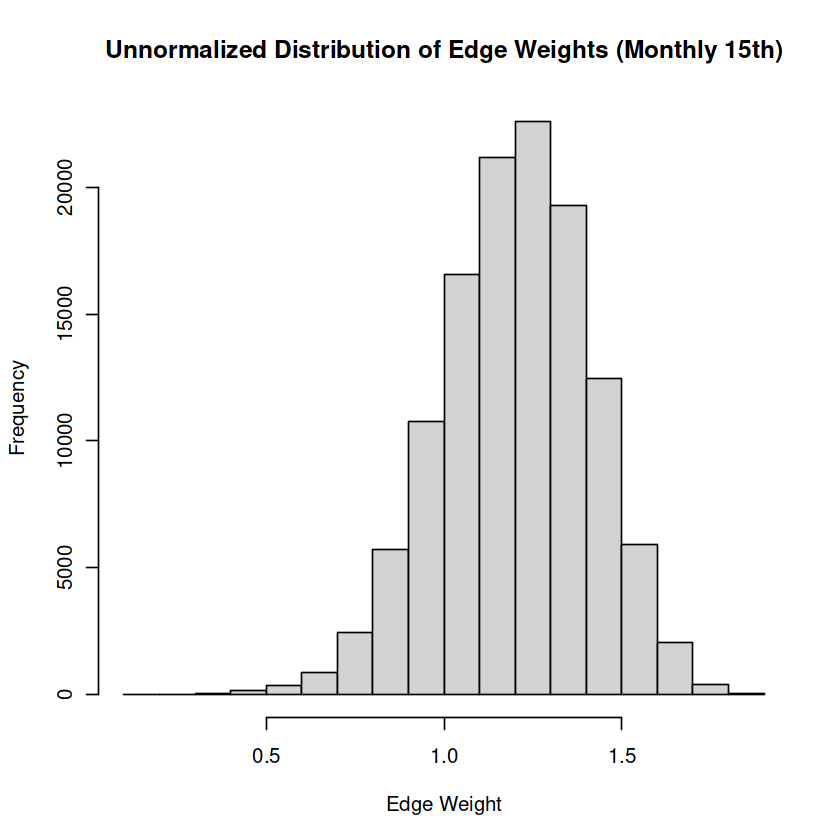

In [21]:
# from helper code
# monthly_15_m  #492x25
monthly_15_cor <- cal_cor(monthly_15_m )
monthly_15_d <- sqrt(2 * (1 - monthly_15_cor)) #check formula from question pdf
month_15_g<-graph_from_adjacency_matrix(monthly_15_d, mode ="upper", weighted = TRUE, diag = TRUE,
  add.colnames = NULL, add.rownames = NA)

hist(E(month_15_g)$weight, main = "Unnormalized Distribution of Edge Weights (Monthly 15th)", xlab = "Edge Weight")

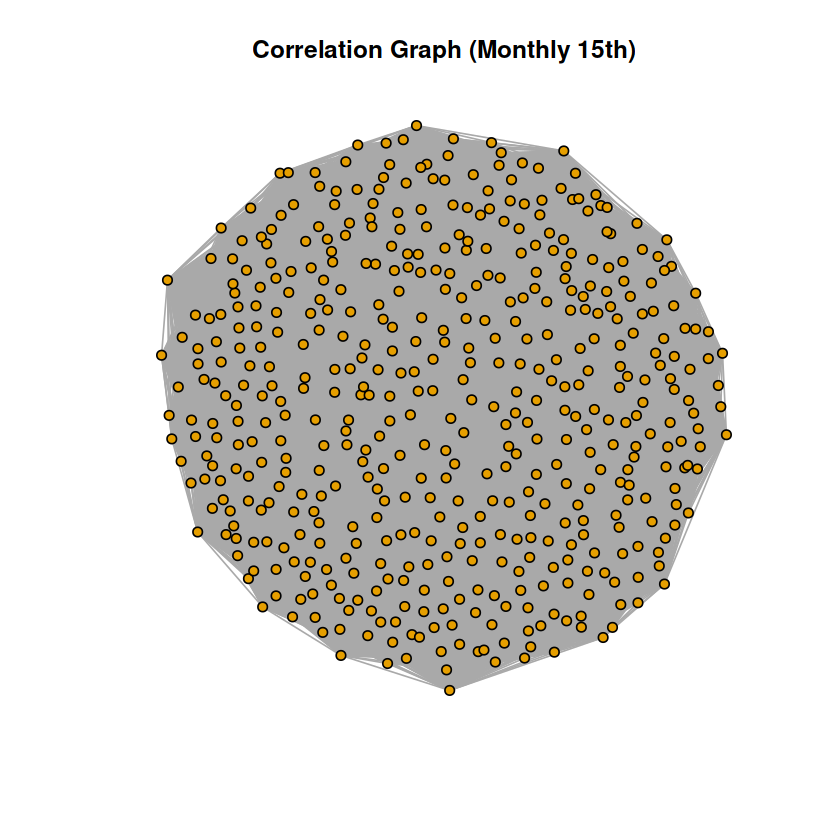

In [22]:
plot(month_15_g, vertex.label=NA, vertex.size=3, main="Correlation Graph (Monthly 15th)")

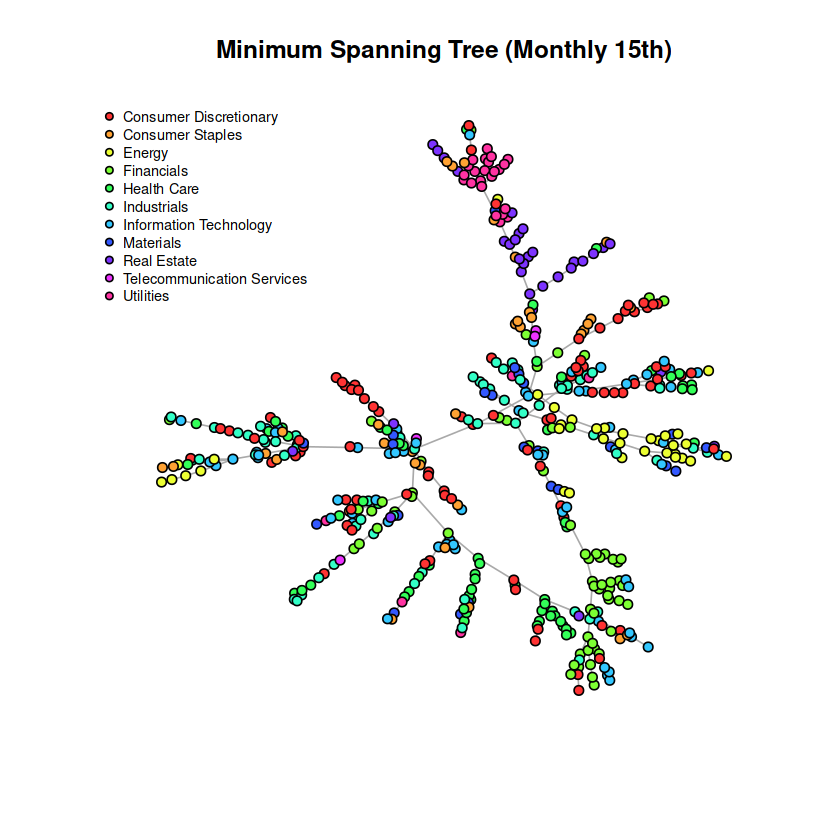

In [23]:
mst_month_15 <- mst(month_15_g, weights = E(month_15_g)$weight) #use the mst function
colbar <- rainbow(num_sector,s = 0.8, v = 1)
plot(mst_month_15, vertex.size=3, vertex.label=NA, vertex.color=colbar[sectors_m.index],
    main = "Minimum Spanning Tree (Monthly 15th)")

legend('topleft',legend=levels(sector_m.set),pch=21, pt.bg=colbar, cex=0.7, bty = "n")

**Q3 Answer:**  Again for the monthly MST, we still have the tree branches, however, the sectors merge even more as we observe fewer single-color branches. The sectors are more intermixed when sampling monthly than when sampling daily or weekly. Almost every branch includes nodes of different colors (sectors). It no longer follows the same sector / color pattern as the daily MST.

[1] 65

[1] "Homegeneity:  0.479447330844778"
[1] "Completeness:  0.277551241133061"


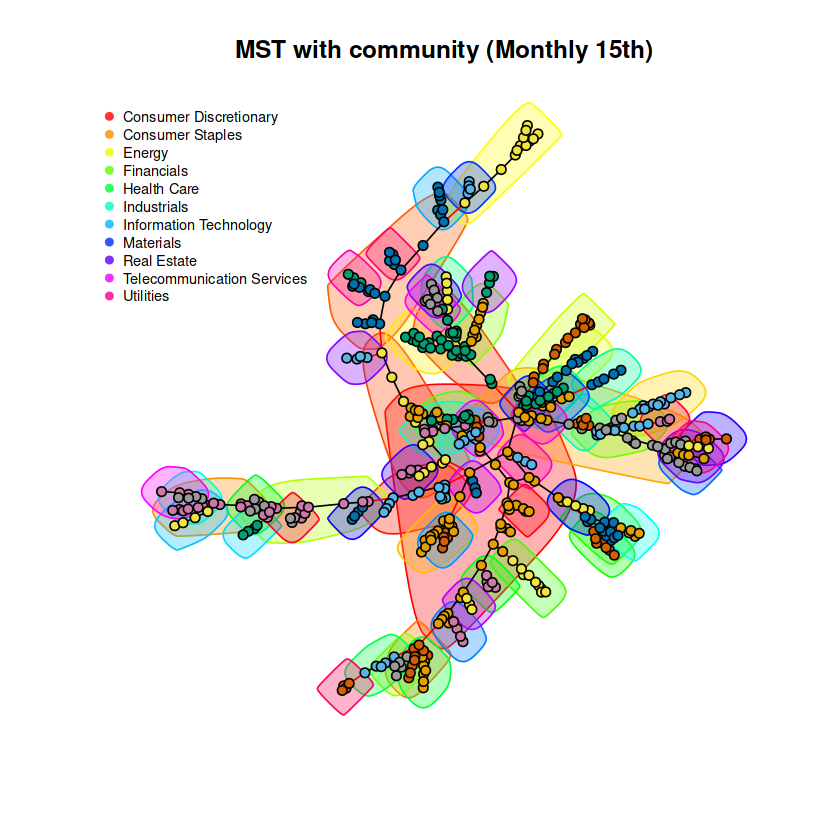

In [24]:
#cluster
wc_monthly <- cluster_walktrap(mst_month_15)
length(wc_monthly)
plot(wc_monthly, mst_month_15, vertex.size=3, vertex.label=NA, 
    vertex.color=sectors_m.index, main="MST with community (Monthly 15th)")
legend("topleft",  
       legend = levels(sector_m.set),
       col = colors, pch=21, pt.bg=colors,
       cex=0.7, bty = "n")

print(paste("Homegeneity: ", homogeneity(sectors_m.index, wc_monthly$membership)))
print(paste("Completeness: ", completeness(sectors_m.index, wc_monthly$membership)))


In [25]:
#get metrics
true<- c(sectors_m.index)
pred <- c(wc_monthly$membership)
homogeneity(true, pred)
completeness(true,pred)

[1] 0.4794473

[1] 0.2775512

In [26]:
V <- vcount(mst_month_15)
P1 <- 0
P2 <- 0
alpha1 <- 0
alpha2 <- 0
Si <- table(sectors_m.index)

for (vi in seq_len(V)){
    # get ni
    ni <- neighbors(mst_month_15, vi)  # neighbors of vi
    # get qi -- ni with same sector as vi
    if (length(ni) > 0)
        {
            current_sector = sectors_m.index[vi]
            qi <- intersect(ni, which(sectors_m.index == current_sector))
            P1 <- P1 + length(qi)/length(ni)
        }
    # get si - sector of vi
    si <- Si[current_sector] 
    #print(paste(current_sector, si, vi))
    P2 <- P2 + si/V
}

alpha1 <- P1/V
alpha2 <- P2/V

print(sprintf("Alpha (Monthly) value for method 1 is: %s",alpha1))
print(sprintf("Alpha (Monthly) value for method 2 is: %s",alpha2))

cat ("P1: ",  P1, "\n")
cat ("P2: ",  P2)

[1] "Alpha (Monthly) value for method 1 is: 0.484446380178087"
[1] "Alpha (Monthly) value for method 2 is: 0.114308612598321"
P1:  238.3476 
P2:  56.23984

**Q5 Answer:**  The alpha value for method 1 is 0.4844, and the alpha value for method 2 is 0.1143. The alpha value for method 1 is higher than the alpha value for method 2, indicating that the first method is still more accurate in predicting the sector of an unknown stock.

## Q8. Compare and analyze all the results of daily data vs weekly data vs monthly data.

What trends do you find? What changes? What remains similar? Give reason for your observations.
 Which granularity gives the best results when predicting the sector of an unknown stock and why?

**Answer:**

Summary of Daily, Weekly, and Monthly Results
|   |  Daily | Weekly | Monthly |
|---|---|---|---|
| **m (data point)** | 765 | 143 | 25 |
| **Homogeneity** | 0.6826 | 0.5811 | 0.4794 |
| **Completeness** | 0.4793 | 0.3900 | 0.2776 |
| **Alpha 1** | 0.8289 | 0.7440 | 0.4844 |
| **Alpha 2** | 0.1142 | 0.1143 | 0.1143 | 
| **Clusters** | 33 | 42 | 65 |

Alpha 2 remains similar across all three sampling frequencies, while alpha 1 decreases as the sampling frequency decreases. Sampling weekly and monthly is less accurate than sampling daily with the closed price. Monthly sampling provides less information (i.e. fewer data points), and thus the observed trends are less clear.  Both Homogeneity and Completeness are lower for weekly and monthly sampling because the stock market is less volatile, and the trends are less clear. Daily sampling is the most accurate because the stock market is the most volatile, and the trends are more defined, as evident in the high alpha 1 value. The number of clusters increases as the sampling frequency decreases, indicating that the data is more segmented and less clustered. This is consistent with the seqmentation of the data, as shown in the monthly MST plots. Note that the monthly number of clusters (65) is almost double of the daily number (33).

Daily sampling is the best for predicting the sector of an unknown stock because it is the most accurate and contains the most information.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=17cbd5eb-edb2-4229-8b04-3518a88921dc' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>